#Visualize Result with original dataset 

In [1]:
#Step 1 Merged Data with Original Data
# Inputs
PROJECT_ROOT = "/Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis"
main_csv = f"{PROJECT_ROOT}/ncr_ride_bookings_with_weather_filled_scaled_short.csv"
pca_csv = f"{PROJECT_ROOT}/unsupervised/kmeans_k5_pca2.csv"
labels_csv = f"{PROJECT_ROOT}/unsupervised/kmeans_k5_labels.csv"
iso_scores = f"{PROJECT_ROOT}/unsupervised/isoforest_scores.csv"
pca_all = f"{PROJECT_ROOT}/unsupervised/pca_2d.csv"

In [5]:
import pandas as pd

# Load all CSVs
df_main   = pd.read_csv(main_csv)
df_labels = pd.read_csv(labels_csv)
df_pca    = pd.read_csv(pca_csv)
df_iso    = pd.read_csv(iso_scores)
df_pca_all = pd.read_csv(pca_all)

print(df_main.shape, df_labels.shape, df_pca.shape, df_iso.shape, df_pca_all.shape)

# Merge step by step on Booking ID and Customer ID
df_merged = (
    df_main
    .merge(df_labels, on=["Booking ID", "Customer ID"], how="left")
    .merge(df_pca, on=["Booking ID", "Customer ID", "cluster"], how="left")
    .merge(df_iso, on=["Booking ID", "Customer ID"], how="left")
    .merge(df_pca_all, on=["Booking ID", "Customer ID"], how="left", suffixes=("", "_all"))
)

print(df_merged.head())
print(df_merged.shape)

(146614, 68) (146614, 3) (146614, 5) (146614, 4) (146614, 4)
         Date      Time  booking_datetime      booking_hour    Booking ID  \
0  2024-03-23  12:29:38  2024-03-23 12:29  2024-03-23 12:00  "CNR5884300"   
1  2024-11-29  18:01:39  2024-11-29 18:01  2024-11-29 18:00  "CNR1326809"   
2  2024-08-23   8:56:10   2024-08-23 8:56   2024-08-23 8:00  "CNR8494506"   
3  2024-10-21  17:17:25  2024-10-21 17:17  2024-10-21 17:00  "CNR8906825"   
4  2024-09-16  22:08:00  2024-09-16 22:08  2024-09-16 22:00  "CNR1950162"   

    Booking Status   Customer ID   Vehicle Type      Pickup Location  \
0  No Driver Found  "CID1982111"          eBike          Palam Vihar   
1       Incomplete  "CID4604802"       Go Sedan        Shastri Nagar   
2        Completed  "CID9202816"           Auto              Khandsa   
3        Completed  "CID2610914"  Premier Sedan  Central Secretariat   
4        Completed  "CID9933542"           Bike     Ghitorni Village   

       Drop Location  ...  precipitation_dr

In [7]:
#feature engineering
#show all columns
pd.set_option('display.max_columns', None)
df_merged

,Date,Time,booking_datetime,booking_hour,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Cancelled Rides by Customer_fill,Reason for cancelling by Customer_fill,Cancelled Rides by Driver_fill,Driver Cancellation Reason_fill,Incomplete Rides_fill,Incomplete Rides Reason_fill,Avg VTAT_fill_scaled,VTAT_missing_flag,CTAT_missing_flag,Avg CTAT_fill_scaled,BookingValue_missing_flag,Booking Value_fill_scaled,Ride Distance_fill_scaled,Driver Ratings_fill,Customer Rating_fill,pick_longitude,pick_latitude,pick_address,pick_region,pick_locality,drop_longitude,drop_latitude,drop_address,drop_region,drop_locality,pick_station_latitude,pick_station_longitude,drop_station_latitude,drop_station_longitude,temperature_2m_scaled,temperature_2m_scaled.1,relative_humidity_2m_scaled,relative_humidity_2m_scaled.1,dew_point_2m_scaled,dew_point_2m_scaled.1,apparent_temperature_scaled,apparent_temperature_scaled.1,wind_speed_10m_scaled,wind_speed_10m_scaled.1,temperature_2m_dropoff_scaled,temperature_2m_dropoff_scaled.1,relative_humidity_2m_dropoff_scaled,relative_humidity_2m_dropoff_scaled.1,dew_point_2m_dropoff_scaled,dew_point_2m_dropoff_scaled.1,apparent_temperature_dropoff_scaled,apparent_temperature_dropoff_scaled.1,wind_speed_10m_dropoff_scaled,wind_speed_10m_dropoff_scaled.1,precipitation_log_scaled,precipitation_log_scaled.1,rain_log_scaled,rain_log_scaled.1,snowfall_log_scaled,snowfall_log_scaled.1,precipitation_dropoff_log_scaled,rain_dropoff_log_scaled,snowfall_dropoff_log_scaled,cluster,pc1,pc2,is_outlier,anomaly_score,pc1_all,pc2_all
0,2024-03-23,12:29:38,2024-03-23 12:29,2024-03-23 12:00,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,0,No Cancellation by Customer,0,No Cancellation by Driver,0,No Incomplete Ride,0.008504,1,1,0.000000,1,-0.013278,0.028481,4.225266,4.405319,77.164401,28.567593,"Palam Marg, Delhi, India",Delhi,Delhi,77.311751,28.670789,"DGD Jhilmil, Delhi, India",Delhi,Delhi,28.567593,77.164401,28.670789,77.311751,0.593750,0.593750,-1.023256,-1.023256,-0.493056,-0.493056,0.015038,0.015038,1.400000,1.400000,0.542056,0.542056,-0.869565,-0.869565,-0.326531,-0.326531,0.075342,0.075342,1.392857,1.392857,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0,34.674352,-0.516413,0,-0.431437,34.674352,-0.516413
1,2024-11-29,18:01:39,2024-11-29 18:01,2024-11-29 18:00,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,0,No Cancellation by Customer,0,No Cancellation by Driver,1,Vehicle Breakdown,-0.654695,0,0,-1.919604,1,-1.334481,-1.420962,4.231475,4.409823,73.897280,18.552377,"Shastri Nagar, Pune, MH, India",Maharashtra,Pune,77.011193,28.489101,"Gurgaon, Gurugram, HR, India",Haryana,Gurugram,18.552377,73.897280,28.489101,77.011193,-0.729167,-0.729167,-0.395349,-0.395349,-0.513889,-0.513889,-0.834586,-0.834586,-0.150000,-0.150000,-1.084112,-1.084112,0.304348,0.304348,-0.217687,-0.217687,-0.945205,-0.945205,-1.250000,-1.250000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0,72.945920,-1.061076,0,-0.430432,72.945920,-1.061076
2,2024-08-23,8:56:10,2024-08-23 8:56,2024-08-23 8:00,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,0,No Cancellation by Customer,0,No Cancellation by Driver,0,No Incomplete Ride,0.919379,0,0,-0.425933,0,0.596213,-0.830293,4.900000,4.900000,82.311070,26.281650,"Khandsara, UP, India",Uttar Pradesh,Khandsara,77.212385,28.534341,"Malviya Nagar, Delhi, India",Delhi,Delhi,26.281650,82.311070,28.534341,77.212385,0.489583,0.489583,0.162791,0.162791,0.680556,0.680556,0.609023,0.609023,-0.100000,-0.100000,0.271028,0.271028,0.282609,0.282609,0.727891,0.727891,0.438356,0.438356,-0.464286,-0.464286,0.182322,0.182322,0.182322,0.182322,0.0,0.0,0.0,0.0,0.0,2,-7.533231,-1.294595,0,-0.408223,-7.533231,-1.294595
3,2024-10-21,17:17:25,2024-10-21 17:17,2024-10-21 17:00,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,0,No Cancellation by Customer,0,No Cancellation b

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact

def plot_clusters(pick_region, vehicle_type, incomplete_flag):
    # Filter by region, vehicle type, and incomplete flag
    df_sample = df_merged[
        (df_merged['pick_region'] == pick_region) &
        (df_merged['Vehicle Type'] == vehicle_type) &
        (df_merged['Incomplete Rides_fill'] == incomplete_flag)
    ]
    
    # Sample for speed
    if len(df_sample) > 2000:
        df_sample = df_sample.sample(5000, random_state=42)
    
    # Convert Time column to datetime & extract hour
    df_sample["Time"] = pd.to_datetime(df_sample["Time"], errors="coerce")
    df_sample["Hour"] = df_sample["Time"].dt.hour
    
    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(18,6))

    # --- Booking Hour vs Value ---
    axes[0].scatter(df_sample["Hour"], df_sample["Booking Value_fill_scaled"],
                    c=df_sample["cluster"], cmap="tab10", s=15, alpha=0.6)
    axes[0].set_title(f"{pick_region} | {vehicle_type} | Incomplete={incomplete_flag}")
    axes[0].set_xlabel("Booking Hour")
    axes[0].set_ylabel("Booking Value (scaled)")

    # --- PCA Scatter ---
    axes[1].scatter(df_sample["pc1"], df_sample["pc2"],
                    c=df_sample["cluster"], cmap="tab10", s=15, alpha=0.6)
    axes[1].set_title("Clusters in PCA Space")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")

    plt.show()

# Build dropdowns from unique values in dataset
interact(
    plot_clusters,
    pick_region=sorted(df_merged['pick_region'].dropna().unique()),
    vehicle_type=sorted(df_merged['Vehicle Type'].dropna().unique()),
    incomplete_flag=sorted(df_merged['Incomplete Rides_fill'].dropna().unique())
)

interactive(children=(Dropdown(description='pick_region', options=('Andhra Pradesh', 'Assam', 'Azad Kashmir', …

<function __main__.plot_clusters(pick_region, vehicle_type, incomplete_flag)>

/var/folders/h7/rdkv64ss4rj67v0yrckxlcdc0000gn/T/ipykernel_13484/1899439543.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sample["Time"] = pd.to_datetime(df_sample["Time"], errors="coerce")


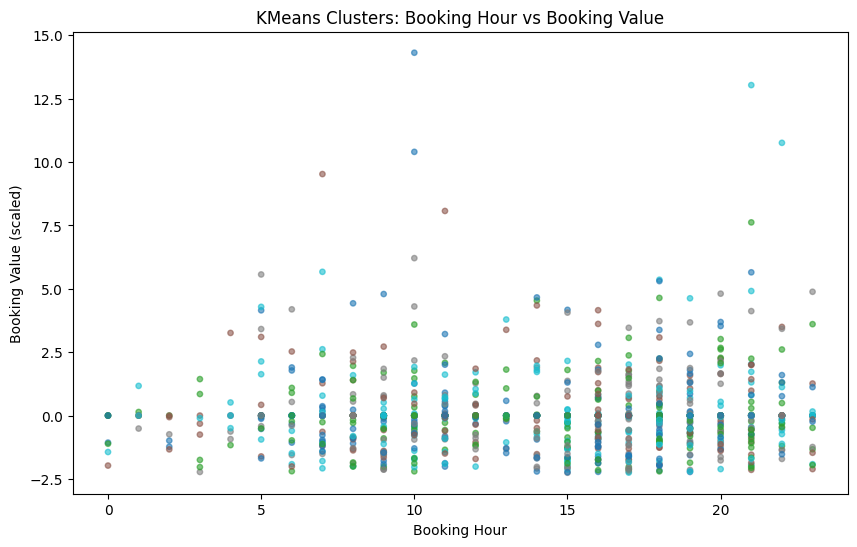

In [23]:
import pandas as pd

# Ensure Time is datetime
df_sample["Time"] = pd.to_datetime(df_sample["Time"], errors="coerce")
df_sample["Hour"] = df_sample["Time"].dt.hour  # extract hour

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df_sample["Hour"], df_sample["Booking Value_fill_scaled"], 
           c=df_sample["cluster"], cmap="tab10", s=15, alpha=0.6)
ax.set_title("KMeans Clusters: Booking Hour vs Booking Value")
ax.set_xlabel("Booking Hour")
ax.set_ylabel("Booking Value (scaled)")
plt.show()

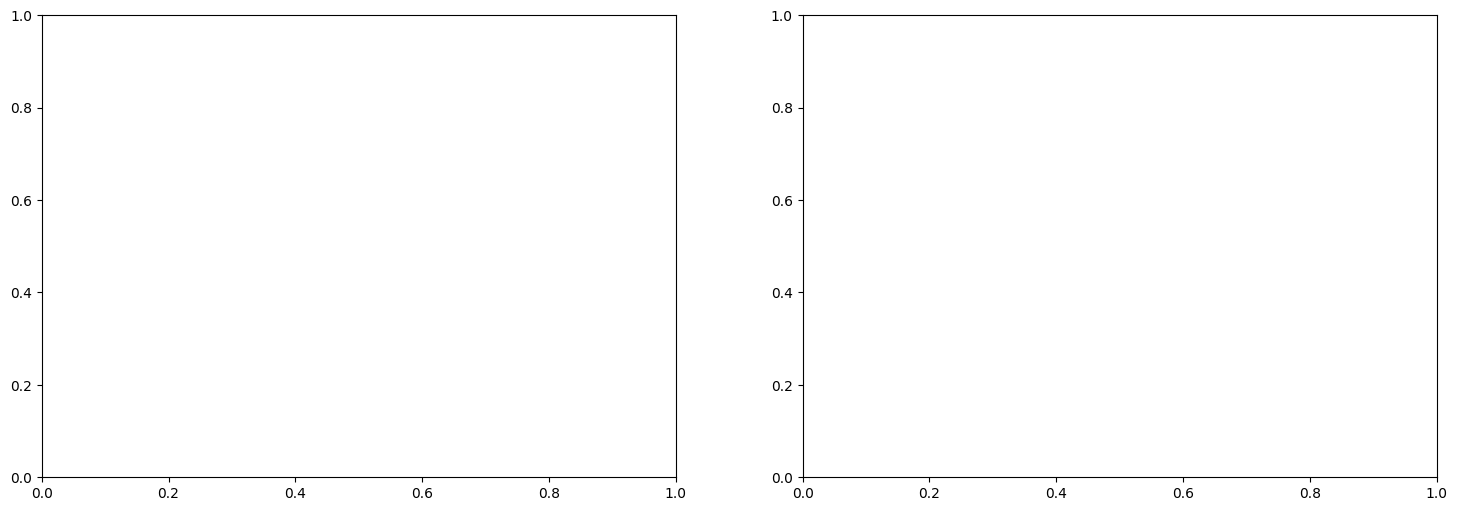

interactive(children=(Dropdown(description='pick_region', options=('Andhra Pradesh', 'Assam', 'Azad Kashmir', …

<function __main__.plot_clusters_umap(pick_region, vehicle_type, incomplete_flag)>

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact

def plot_clusters_umap(pick_region, vehicle_type, incomplete_flag):
    # Filter by region, vehicle type, and incomplete flag
    df_sample = df_umap.merge(df_merged, on=["Booking ID","Customer ID"], how="left")
    df_sample = df_sample[
        (df_sample['pick_region'] == pick_region) &
        (df_sample['Vehicle Type'] == vehicle_type) &
        (df_sample['Incomplete Rides_fill'] == incomplete_flag)
    ]
    
    # Sample for speed
    if len(df_sample) > 2000:
        df_sample = df_sample.sample(2000, random_state=42)
    
    # Convert Time column to datetime & extract hour
    df_sample["Time"] = pd.to_datetime(df_sample["Time"], errors="coerce")
    df_sample["Hour"] = df_sample["Time"].dt.hour
    
    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(18,6))

    # --- Booking Hour vs Value ---
    axes[0].scatter(df_sample["Hour"], df_sample["Booking Value_fill_scaled"],
                    c=df_sample["cluster"], cmap="tab10", s=15, alpha=0.6)
    axes[0].set_title(f"{pick_region} | {vehicle_type} | Incomplete={incomplete_flag}")
    axes[0].set_xlabel("Booking Hour")
    axes[0].set_ylabel("Booking Value (scaled)")

    # --- UMAP Scatter ---
    axes[1].scatter(df_sample["umap1"], df_sample["umap2"],
                    c=df_sample["cluster"], cmap="tab10", s=15, alpha=0.6)
    axes[1].set_title("Clusters in UMAP Space")
    axes[1].set_xlabel("UMAP1")
    axes[1].set_ylabel("UMAP2")

    plt.show()

# Dropdowns
interact(
    plot_clusters_umap,
    pick_region=sorted(df_merged['pick_region'].dropna().unique()),
    vehicle_type=sorted(df_merged['Vehicle Type'].dropna().unique()),
    incomplete_flag=sorted(df_merged['Incomplete Rides_fill'].dropna().unique())
)

In [28]:
import umap
import pandas as pd

# 1. Extract features for UMAP (scaled numeric only)
X = df_merged.select_dtypes(include=['float64','int64'])

# 2. Run UMAP
umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X)

# 3. Build df_umap with UMAP coordinates + IDs
df_umap = pd.DataFrame(X_umap, columns=["umap1", "umap2"])
df_umap["Booking ID"] = df_merged["Booking ID"].values
df_umap["Customer ID"] = df_merged["Customer ID"].values

# (Optional) add cluster labels from your kmeans_k5_labels.csv
df_umap = df_umap.merge(df_labels, on=["Booking ID","Customer ID"], how="left")

df_umap.head()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,umap1,umap2,Booking ID,Customer ID,cluster
0,7.559537,7.048127,"""CNR5884300""","""CID1982111""",0
1,11.408882,8.812165,"""CNR1326809""","""CID4604802""",0
2,3.256745,5.114804,"""CNR8494506""","""CID9202816""",2
3,-2.864971,7.736291,"""CNR8906825""","""CID2610914""",4
4,-1.362261,6.436267,"""CNR1950162""","""CID9933542""",4


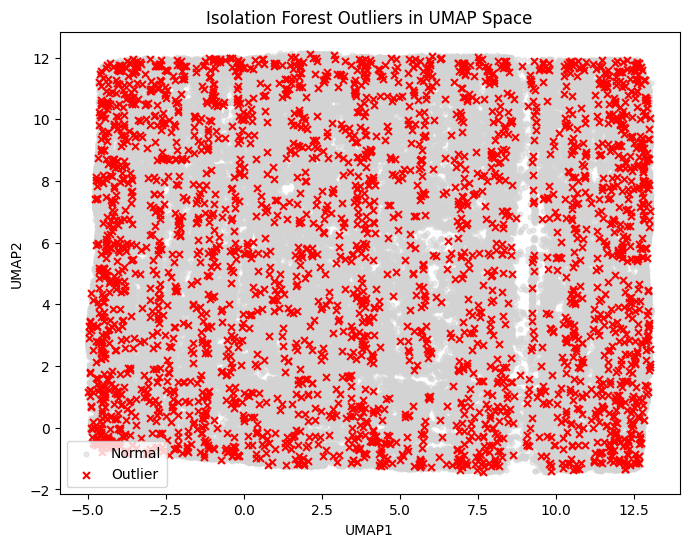

In [31]:
# Merge UMAP with anomaly scores
df_umap_iso = df_umap.merge(df_iso, on=["Booking ID","Customer ID"], how="left")

plt.figure(figsize=(8,6))
plt.scatter(df_umap_iso.loc[df_umap_iso['is_outlier']==0, 'umap1'],
            df_umap_iso.loc[df_umap_iso['is_outlier']==0, 'umap2'],
            c="lightgray", s=12, alpha=0.5, label="Normal")
plt.scatter(df_umap_iso.loc[df_umap_iso['is_outlier']==1, 'umap1'],
            df_umap_iso.loc[df_umap_iso['is_outlier']==1, 'umap2'],
            c="red", marker="x", s=25, label="Outlier")

plt.title("Isolation Forest Outliers in UMAP Space")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend()
plt.show()

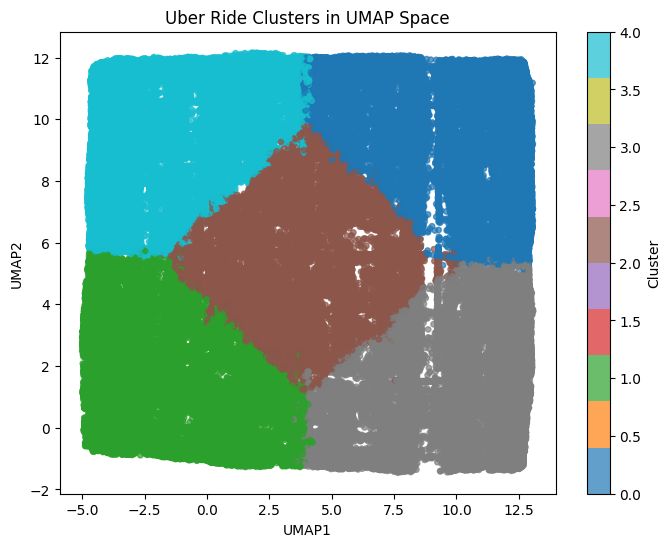

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_umap["umap1"], df_umap["umap2"],
            c=df_umap["cluster"], cmap="tab10", s=15, alpha=0.7)

plt.title("Uber Ride Clusters in UMAP Space")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(label="Cluster")
plt.show()

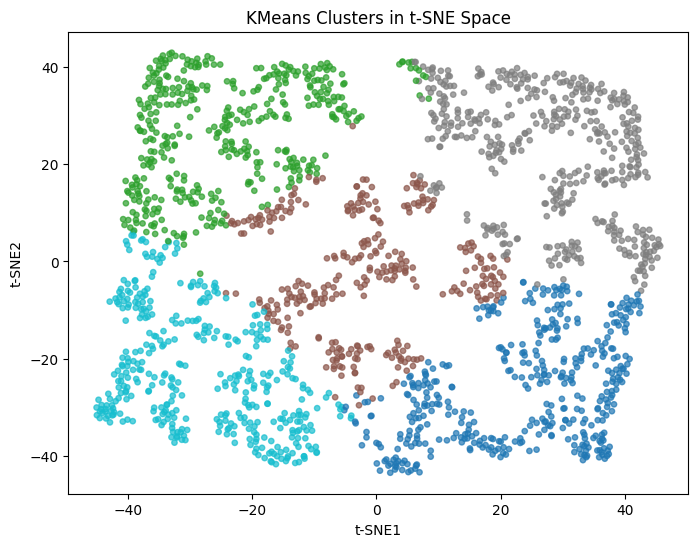

In [33]:
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt

# Use scaled numeric features
X = df_merged.select_dtypes(include=['float64','int64'])

# Run t-SNE (sample for speed, e.g., 2000 rows)
X_sample = X.sample(2000, random_state=42)

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

# Put into dataframe
df_tsne = pd.DataFrame(X_tsne, columns=["tsne1", "tsne2"])
df_tsne["Booking ID"] = df_merged.sample(2000, random_state=42)["Booking ID"].values
df_tsne["Customer ID"] = df_merged.sample(2000, random_state=42)["Customer ID"].values

# Merge with clusters
df_tsne = df_tsne.merge(df_labels, on=["Booking ID","Customer ID"], how="left")

# Plot
plt.figure(figsize=(8,6))
plt.scatter(df_tsne["tsne1"], df_tsne["tsne2"], 
            c=df_tsne["cluster"], cmap="tab10", s=15, alpha=0.7)
plt.title("KMeans Clusters in t-SNE Space")
plt.xlabel("t-SNE1")
plt.ylabel("t-SNE2")
plt.show()